In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE "user_%"
"""
df = pd.read_sql(query, connect, parse_dates=['timestamp'])
df['night']   = (df['timestamp'].dt.hour >= 0)  & (df['timestamp'].dt.hour < 4)
df['morning'] = (df['timestamp'].dt.hour >= 4)  & (df['timestamp'].dt.hour < 10)
df['afternoon'] = (df['timestamp'].dt.hour >= 10) & (df['timestamp'].dt.hour < 17)
df['evening'] = (df['timestamp'].dt.hour >= 17) & (df['timestamp'].dt.hour < 24)
df = df[['night','morning','afternoon','evening']].groupby(df['timestamp'].dt.date).sum()
df.index.name = 'date'

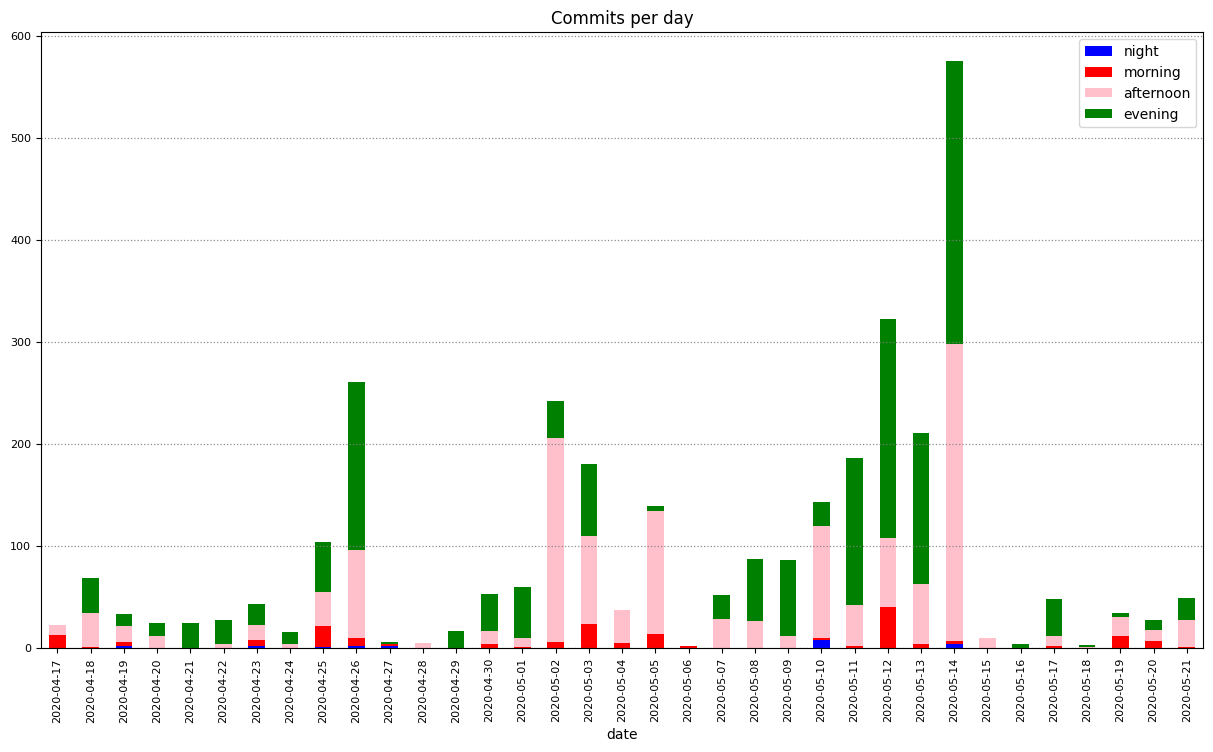

In [8]:
ax = df.plot(
    title='Commits per day',
    fontsize=8,
    figsize=(15,8),
    rot= 90,
    kind='bar',
    stacked=True,
    color=['blue', 'red', 'pink', 'green'],
);

ax.grid(axis='y', color='gray', linestyle=':', alpha=0.9, linewidth=0.9)

In [9]:
df.shape

(35, 4)

In [10]:
connect.close()

## Когда наши пользователи обычно выполняют лабораторные работы: днем или вечером

##  2020-05-14 наибольшее кол-во коммитов

## в этот день коммитов больше вечером

## Ответ: 2020-05-14